In [1]:
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_RNA.h5ad
!wget -nc https://zenodo.org/record/7041849/files/PapalexiSatija2021_eccite_protein.h5ad
!pip install pyro-ppl graphviz seaborn anndata

File ‘PapalexiSatija2021_eccite_RNA.h5ad’ already there; not retrieving.

File ‘PapalexiSatija2021_eccite_protein.h5ad’ already there; not retrieving.


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import multiprocessing

multiprocessing.cpu_count()

10

In [3]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import pyro
import pyro.distributions as dist
from pyro.infer import (
    SVI,
    TraceEnum_ELBO,
    Trace_ELBO,
    TraceMeanField_ELBO,
    JitTraceEnum_ELBO,
    config_enumerate,
    infer_discrete,
)

from torch.utils.data import (
    Dataset,
    Sampler,
    DataLoader,
    WeightedRandomSampler,
    SubsetRandomSampler,
    BatchSampler,
)

from pyro.optim import Adam, ClippedAdam
from pyro.ops.indexing import Vindex

from pyro import poutine, render_model
from pyro.infer.autoguide import AutoNormal, AutoDelta, init_to_median, init_to_value
import sys
from tqdm import tqdm

if torch.cuda.is_available():
    print("Let's ride")
    device = "cuda"
    torch.set_float32_matmul_precision("high")
    # torch.set_default_device("cuda")
    smoke_test = False
else:
    device = "cpu"
    smoke_test = True
smoke_test = True


In [4]:
adata = ad.read("PapalexiSatija2021_eccite_RNA.h5ad")
adata

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


AnnData object with n_obs × n_vars = 20729 × 18649
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [5]:
prot_adata = ad.read("PapalexiSatija2021_eccite_protein.h5ad")
prot_adata.var_names = prot_adata.var_names + "_protein"

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


In [6]:
prot_df = prot_adata.to_df().join(prot_adata.obs)
prot_df


,CD86_protein,PDL1_protein,PDL2_protein,CD366_protein,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,...,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,118.0,522.0,94.0,67.0,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,801.0,0.0,0.0
AAACCTGAGTGGACGT,243.0,139.0,104.0,59.0,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,545.0,0.0,0.0
AAACCTGCATGAGCGA,99.0,109.0,56.0,80.0,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,344.0,0.0,0.0
AAACCTGTCTTGTCAT,110.0,334.0,48.0,47.0,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,539.0,0.0,0.0
AAACGGGAGAACAACT,303.0,593.0,77.0,80.0,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,1053.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,98.0,151.0,135.0,14.0,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,398.0,0.0,0.0
TTTGTCAGTGACGGTA,1781.0,1117.0,89.0,55.0,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,0,4,3042.0,0.0,0.0
TTTGTCAGTTCCACAA,84.0,73.0,38.0,17.0,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,212.0,0.0,0.0
TTTGTCATCACGCATA,18.0,135.0,37.0,68.0,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,...,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4,258.0,0.0,0.0


In [7]:
# adata = ad.concat((prot_adata, adata), axis=1, merge="first")
# adata

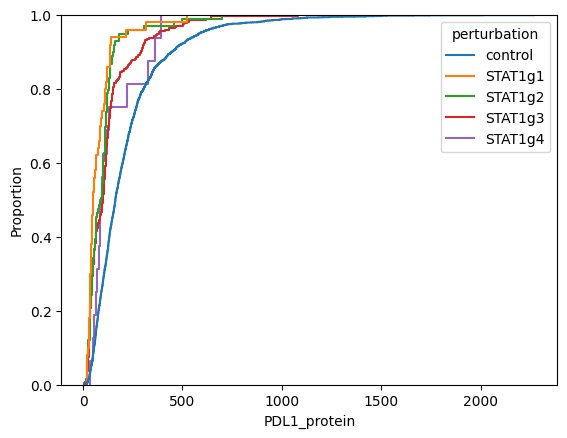

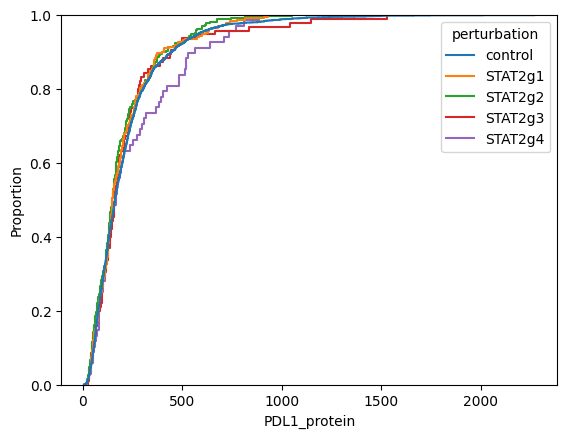

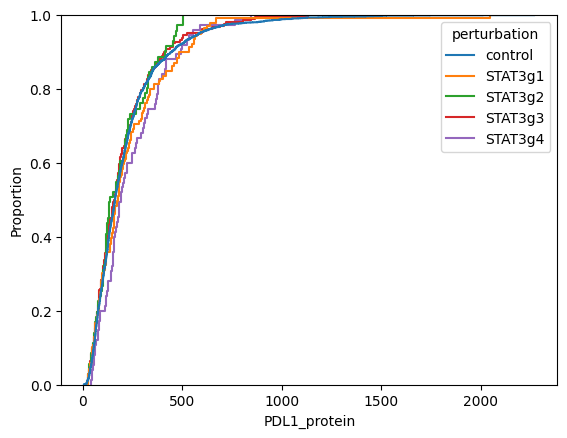

In [8]:
plot_gene = "STAT1"
for plot_gene in ["STAT1", "STAT2", "STAT3"]:
    sns.ecdfplot(prot_df, hue="perturbation", x="PDL1_protein", hue_order=["control"]+[f"{plot_gene}g{i}" for i in range(1,5)])
    plt.show()

In [9]:
adata.obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578


In [10]:
n_mito = adata[:, adata.var_names.str.startswith("MT-")].X.sum(axis=1).A1
n_rps = adata[:, adata.var_names.str.match("RPS[0-9]+")].X.sum(axis=1).A1
n_rpl = adata[:, adata.var_names.str.match("RPL[0-9]+")].X.sum(axis=1).A1
n_ribo = n_rps + n_rpl
n_total = adata.X.sum(axis=1).A1
# adata.obs
# plt.scatter(n_total, n_ribo, alpha=0.1)
# plt.scatter(n_total, n_mito, alpha=0.1)
# plt.scatter(n_ribo, n_mito, alpha=0.1)

In [11]:
adata.obs = adata.obs.assign(
    element=lambda x: x["perturbation"].str.replace("g[0-9]+$", "", regex=True)
)
adata.obs["element"]

AAACCTGAGCCAGAAC      STAT2
AAACCTGAGTGGACGT       CAV1
AAACCTGCATGAGCGA      STAT1
AAACCTGTCTTGTCAT       CD86
AAACGGGAGAACAACT       IRF7
                     ...   
TTTGTCAGTCACTTCC      CMTM6
TTTGTCAGTGACGGTA    control
TTTGTCAGTTCCACAA       ATF2
TTTGTCATCACGCATA       CAV1
TTTGTCATCTGTACGA      STAT3
Name: element, Length: 20729, dtype: object

In [12]:
# pick a subset of random genes including 3 known ones
# stat_target_genes = ["STAT1", "STAT2", "IRF1"]

# pick a subset of 50 genes including all perturbed ones

if smoke_test:
    n_genes_subset = 50
    target_genes = [e for e in adata.obs["element"].unique() if e != "control"]
    # target_genes += prot_adata.var_names.tolist()
    other_genes = [gene for gene in adata.var_names if gene not in target_genes]
    selected_genes = target_genes + other_genes[: n_genes_subset - len(target_genes)]
    # selected_genes = stat_target_genes + list(
    #     np.random.choice(other_genes, size=n_genes_subset - len(stat_target_genes))
    # )

    # selected_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
    # guide_filter = adata.obs["perturbation"].isin(selected_guides)
    # adata_subset = adata[guide_filter, :][:, selected_genes]
    adata_subset = adata[:, selected_genes]

else:
    min_counts = 100 # min no. of cells with at least 1 count
    selected_genes = ((adata.X>0).sum(axis=0)) > min_counts
    adata_subset = adata[:, selected_genes]
adata_subset

View of AnnData object with n_obs × n_vars = 20729 × 50
    obs: 'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [13]:
adata_subset.var_names

Index(['STAT2', 'CAV1', 'STAT1', 'CD86', 'IRF7', 'ATF2', 'STAT3', 'JAK2',
       'NFKBIA', 'SMAD4', 'STAT5A', 'CMTM6', 'IFNGR1', 'UBE2L6', 'PDCD1LG2',
       'CUL3', 'BRD4', 'MARCH8', 'IRF1', 'POU2F2', 'ETV7', 'IFNGR2',
       'TNFRSF14', 'SPI1', 'MYC', 'AL627309.1', 'AP006222.2', 'RP4-669L17.10',
       'RP11-206L10.3', 'RP11-206L10.2', 'RP11-206L10.9', 'LINC00115',
       'FAM41C', 'SAMD11', 'NOC2L', 'KLHL17', 'PLEKHN1', 'HES4', 'ISG15',
       'AGRN', 'RP11-54O7.18', 'C1orf159', 'TNFRSF18', 'TNFRSF4', 'SDF4',
       'B3GALT6', 'FAM132A', 'RP5-902P8.12', 'UBE2J2', 'SCNN1D'],
      dtype='object', name='gene_symbol')

In [14]:
# from siphon.module import train
import mudata as md
grna_observed = pd.get_dummies(adata_subset.obs["guide_id"]).astype(int)

In [15]:
guide_by_element = (
    pd.crosstab(adata_subset.obs["guide_id"], adata_subset.obs["element"])
    .reindex(index=grna_observed.columns)
    > 0
).astype(int)
guide_by_element

element,ATF2,BRD4,CAV1,CD86,CMTM6,CUL3,ETV7,IFNGR1,IFNGR2,IRF1,...,POU2F2,SMAD4,SPI1,STAT1,STAT2,STAT3,STAT5A,TNFRSF14,UBE2L6,control
ATF2g1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ATF2g4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BRD4g1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TNFRSF14g4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
UBE2L6g1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
UBE2L6g3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [16]:

gdata = ad.AnnData(grna_observed, varm={"guide_targets": guide_by_element})
mdata = md.MuData({"rna":adata_subset, "grna":gdata})
mdata

MuData object with n_obs × n_vars = 20729 × 157
  2 modalities
    rna:	20729 x 50
      obs:	'hto', 'guide_id', 'hto_barcode', 'gdo_barcode', 'perturbation', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'element'
      var:	'ensembl_id', 'ncounts', 'ncells'
    grna:	20729 x 107
      varm:	'guide_targets'

In [17]:
mdata["rna"].obs

,hto,guide_id,hto_barcode,gdo_barcode,perturbation,tissue_type,cell_line,cancer,disease,perturbation_type,celltype,organism,nperts,ngenes,ncounts,percent_mito,percent_ribo,element
AAACCTGAGCCAGAAC,rep1-tx,STAT2g2,AGGACCATCCAA,CTTCGTGTACGGTTGCACA,STAT2g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3942,17207.0,2.295577,14.714942,STAT2
AAACCTGAGTGGACGT,rep1-tx,CAV1g4,AGGACCATCCAA,GTCTACGTATTTGCCCCCA,CAV1g4,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2948,9506.0,4.512939,9.877972,CAV1
AAACCTGCATGAGCGA,rep1-tx,STAT1g2,AGGACCATCCAA,CATCCTTTGGTACAACATG,STAT1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4258,15256.0,4.116413,13.227583,STAT1
AAACCTGTCTTGTCAT,rep1-tx,CD86g1,AGGACCATCCAA,ATTCCTTGGATTACAGCTG,CD86g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,1780,5135.0,5.491723,21.888997,CD86
AAACGGGAGAACAACT,rep1-tx,IRF7g2,AGGACCATCCAA,CCAGTACACCTTGCACTTG,IRF7g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,2671,9673.0,3.359868,13.263724,IRF7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTCACTTCC,rep3-tx,CMTM6g1,AGGACCATCCAA,CGTAGTGGGGCTGTACACC,CMTM6g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4884,20863.0,5.469012,13.914586,CMTM6
TTTGTCAGTGACGGTA,rep4-tx,NTg4,TCGATAATGCGA,TGCGACGCTTAGCCTCCGT,control,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,0,3787,17553.0,2.159175,7.673902,control
TTTGTCAGTTCCACAA,rep3-tx,ATF2g1,AGGACCATCCAA,TTCATTTCTCAGCAGGGTG,ATF2g1,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,4185,15106.0,2.661194,14.338673,ATF2
TTTGTCATCACGCATA,rep3-tx,CAV1g2,AGGACCATCCAA,GTCATCGTTGAGGTGTTTA,CAV1g2,cell_line,THP-1,True,acute monocytic leukemia,CRISPR,monocytes,human,1,3204,11209.0,7.369078,10.036578,CAV1


In [18]:
import perturbo
perturbo.PERTURBO.setup_mudata(
    mdata,
    batch_key="hto",
    library_size_key="ncounts",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    guide_by_element_key="guide_targets",
    # gene_by_element_key="element_tested",
    modalities={
        "rna_layer": "rna",
        "perturbation_layer": "grna",
    },
)

model = perturbo.PERTURBO(mdata, likelihood="nb", low_moi=True, n_factors=3, n_pert_factors=10)
model.view_anndata_setup()


/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


INFO     Using column names from columns of adata.varm['guide_targets']                                            


/Users/ljb80/Projects/perturbo/src/perturbo/models/_model.py:231: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mdata[modalities.rna_layer].obs[size_factor_key] = log_cpm - log_cpm.mean()
<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

<frozen abc>:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

/Users/ljb80/.virtualenvs/perturbo-dev/lib/pyth

Anndata setup with scvi-tools version 1.0.4.

Setup via `PERTURBO.setup_anndata` with arguments:

...

        Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃    Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch         │   5   │
│         n_cells         │ 20729 │
│ n_extra_continuous_covs │   2   │
│  n_gene_summary_stats   │   1   │
│     n_perturbations     │  107  │
│   n_targeted_elements   │  26   │
│         n_vars          │  50   │
└─────────────────────────┴───────┘

                                 Data Registry                                  
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃                 scvi-tools Location                  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.mod['rna'].X                  │
│         batch         │         adata.mod['rna'].obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.mod['rna'].obsm['_scvi_extra_continuous_covs'] │
│  gene_summary_stats   │  adata.mod['rna'].varm['_scvi_gene_summary_stats']   │
│         ind_x         │            adata.mod['rna'].obs['_ind_x']            │
│     perturbations     │                 adata.mod['grna'].X                  │
│      size_factor      │         adata.mod['rna'].obs['_size_factor']         │
│   targeted_elements   │       adata.mod['grna'].varm['guide_targets']        │
└───────────────────────┴──────────────────────────────────────────────────────┘

                 batch State Registry                  
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Source Location  ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['hto'] │  rep1-tx   │          0          │
│                  │ rep2-ctrl  │          1          │
│                  │  rep2-tx   │          2          │
│                  │  rep3-tx   │          3          │
│                  │  rep4-tx   │          4          │
└──────────────────┴────────────┴─────────────────────┘

 gene_summary_stats State  
         Registry          
┏━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.var['_gene_mean'] │
└─────────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
│ adata.obs['percent_ribo'] │
└───────────────────────────┘

In [19]:
model.train(
    100,
    lr=0.01,
    batch_size=512,
    # callbacks=[checkpoint_callback],
    # enable_checkpointing=True,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_min_delta=1e-3,
    early_stopping_monitor="elbo_train",
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 66/100:  66%|██████▌   | 66/100 [01:12<00:37,  1.09s/it, v_num=1, elbo_train=1.02e+6]
Monitored metric elbo_train did not improve in the last 5 records. Best score: 1019521.438. Signaling Trainer to stop.


In [20]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)


AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.scales.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([3, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([3, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([3, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([3, 1, 50])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuide

In [21]:
# plt.scatter(siphon_model.dataset.size_factor, siphon_model.guide.median()["size_factor_fit"], alpha=0.01)

In [23]:
# plt.plot(losses)

In [24]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)

AutoGuideList.0.locs.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.scales.guide_efficacy torch.Size([107, 1])
AutoGuideList.0.locs.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.scales.pert_factors torch.Size([10, 26, 1])
AutoGuideList.0.locs.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.scales.pert_loadings torch.Size([10, 1, 50])
AutoGuideList.0.locs.cell_factors torch.Size([3, 20729, 1])
AutoGuideList.0.scales.cell_factors torch.Size([3, 20729, 1])
AutoGuideList.0.locs.cell_loadings torch.Size([3, 1, 50])
AutoGuideList.0.scales.cell_loadings torch.Size([3, 1, 50])
AutoGuideList.0.locs.log_gene_mean torch.Size([50])
AutoGuideList.0.scales.log_gene_mean torch.Size([50])
AutoGuideList.0.locs.log_gene_dispersion torch.Size([50])
AutoGuideList.0.scales.log_gene_dispersion torch.Size([50])
AutoGuideList.0.locs.batch_effect torch.Size([5, 50])
AutoGuideList.0.scales.batch_effect torch.Size([5, 50])
AutoGuideList.0.locs.cont_covariate_effect torch.Size([3, 50])
AutoGuide

In [27]:
guide=model.module.guide
guide.median()

{'guide_efficacy': tensor([[0.4733],
         [0.6223],
         [0.7516],
         [0.4910],
         [0.9521],
         [0.9212],
         [0.6140],
         [0.6669],
         [0.5418],
         [0.5855],
         [0.5253],
         [0.7389],
         [0.4229],
         [0.8020],
         [0.4687],
         [0.5105],
         [0.6415],
         [0.1847],
         [0.8090],
         [0.6900],
         [0.9457],
         [0.8490],
         [0.9061],
         [0.1806],
         [0.6984],
         [0.1784],
         [0.9351],
         [0.5271],
         [0.9802],
         [0.6658],
         [0.9784],
         [0.7442],
         [0.7300],
         [0.6224],
         [0.2088],
         [0.2907],
         [0.9176],
         [0.9789],
         [0.5238],
         [0.8248],
         [0.8313],
         [0.7292],
         [0.7847],
         [0.8458],
         [0.8473],
         [0.9892],
         [0.6642],
         [0.5154],
         [0.6429],
         [0.5303],
         [0.8841],
         [0.8

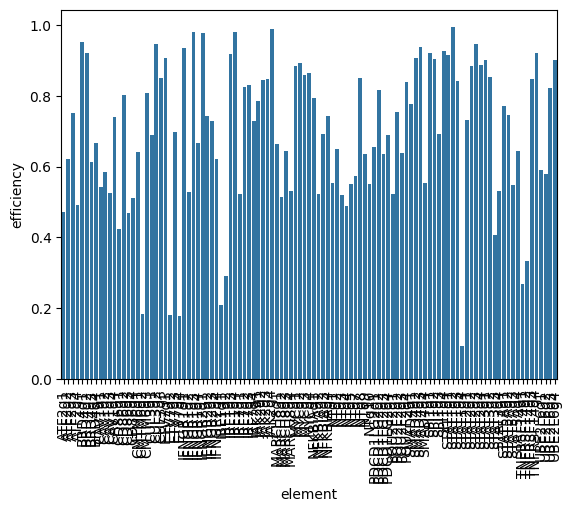

In [30]:
elements = guide_by_element.index
if "guide_efficacy" in guide.median():
    element_efficiency = pd.DataFrame(
        guide.median()["guide_efficacy"].detach().cpu(),
        index=elements,
        columns=["efficiency"],
    ).reset_index(names="element")
    element_efficiency
    sns.barplot(element_efficiency, x="element", y="efficiency")
    plt.xticks(rotation=90)

In [36]:
median_efficiency = pd.DataFrame(
    guide.median()["guide_efficacy"].detach().cpu(),
    index=guides,
    columns=["efficiency"],
).assign(
    guide=lambda x: x.index,
    element=lambda x: x.index.str.replace("g[0-9]+$", "", regex=True),
)
median_efficiency.hist("efficiency")

AttributeError: Can only use .str accessor with string values!

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25],
 [Text(0, 0, 'control'),
  Text(1, 0, 'ATF2'),
  Text(2, 0, 'BRD4'),
  Text(3, 0, 'CAV1'),
  Text(4, 0, 'CD86'),
  Text(5, 0, 'CMTM6'),
  Text(6, 0, 'CUL3'),
  Text(7, 0, 'ETV7'),
  Text(8, 0, 'IFNGR1'),
  Text(9, 0, 'IFNGR2'),
  Text(10, 0, 'IRF1'),
  Text(11, 0, 'IRF7'),
  Text(12, 0, 'JAK2'),
  Text(13, 0, 'MARCH8'),
  Text(14, 0, 'MYC'),
  Text(15, 0, 'NFKBIA'),
  Text(16, 0, 'PDCD1LG2'),
  Text(17, 0, 'POU2F2'),
  Text(18, 0, 'SMAD4'),
  Text(19, 0, 'SPI1'),
  Text(20, 0, 'STAT1'),
  Text(21, 0, 'STAT2'),
  Text(22, 0, 'STAT3'),
  Text(23, 0, 'STAT5A'),
  Text(24, 0, 'TNFRSF14'),
  Text(25, 0, 'UBE2L6')])

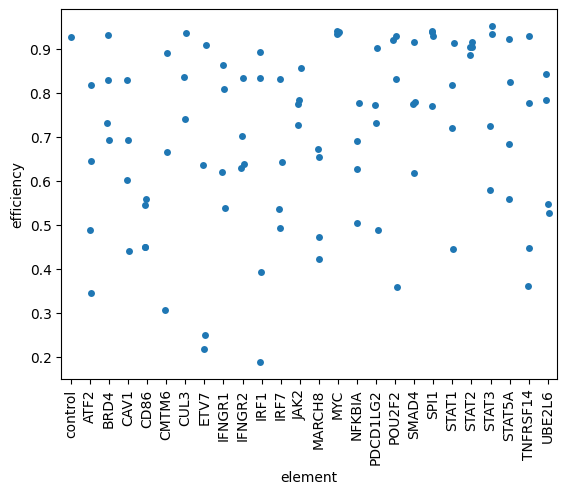

In [24]:
sns.stripplot(median_efficiency, x="element", y="efficiency")
plt.xticks(rotation=90)

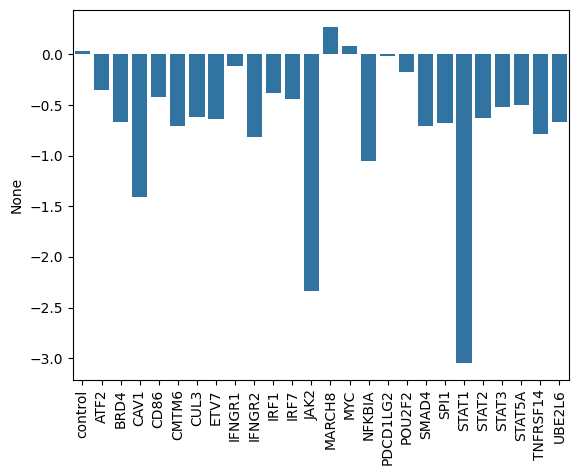

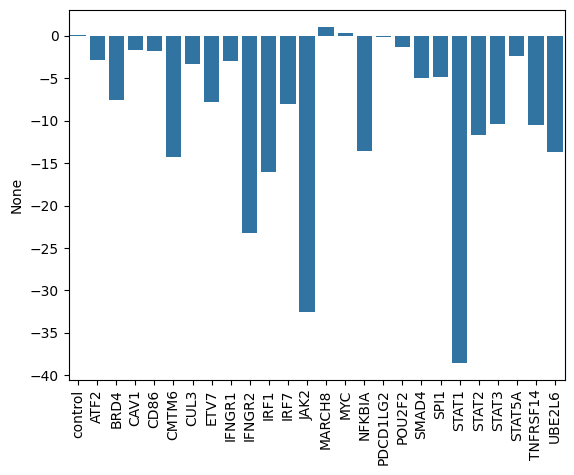

In [25]:
median_cis_effect = guide.median()["cis_effect"].detach().cpu()
low_cis_effect, high_cis_effect = (
    guide.quantiles([0.159, 0.841])["cis_effect"].detach().cpu()
)
sigma_cis_effect = high_cis_effect - median_cis_effect
z_score_cis_effect = median_cis_effect / sigma_cis_effect

sns.barplot(x=elements, y=median_cis_effect.squeeze())
plt.xticks(rotation=90)
plt.show()

sns.barplot(x=elements, y=z_score_cis_effect.squeeze())

plt.xticks(rotation=90)
plt.show()

In [26]:
# sns.stripplot(guide.median()["effect"])
# # print(n_guides)
# from numpy import median

median_effect = guide.median()["trans_effect"].detach().cpu()
low_effect, high_effect = guide.quantiles([0.159, 0.841])["trans_effect"].detach().cpu()
sigma_effect = high_effect - low_effect
z_score_effect = median_effect / sigma_effect

effects_df = pd.DataFrame(
    median_effect,
    # z_score_effect,
    columns=adata_subset.var_names,
    index=elements,
)
effects_df

# effects_df = pd.DataFrame(
#     median_effect,
#     columns=adata_subset.var_names,
#     index=list(element_mapping.keys())[:n_elements],
# )
# effects_df

gene_symbol,STAT2,CAV1,STAT1,CD86,IRF7,ATF2,STAT3,JAK2,NFKBIA,SMAD4,...,RP11-54O7.18,C1orf159,TNFRSF18,TNFRSF4,SDF4,B3GALT6,FAM132A,RP5-902P8.12,UBE2J2,SCNN1D
control,-0.003379,0.006233,-0.002653,0.001373,-0.017096,0.012876,-0.003926,-0.001281,-0.007357,-0.000992,...,0.018454,-0.000136,-0.012498,-0.007736,0.016405,-0.013938,-0.008955,-0.001910,-0.003047,0.006306
ATF2,-0.128596,0.008434,-0.000574,0.012430,-0.230050,0.004157,-0.017916,-0.014227,0.022273,0.005456,...,0.000593,0.033427,0.003519,0.008968,0.016301,0.007095,-0.018033,-0.011000,0.009292,-0.011038
BRD4,-0.077348,0.006086,-0.014659,-1.179363,-0.583943,-0.009966,0.015913,0.016888,0.368439,-0.037782,...,-0.000967,-0.007546,-0.002168,-0.006535,0.005624,0.012306,-0.016951,-0.013698,-0.008169,0.007368
CAV1,-0.026516,0.001728,-0.010437,0.000027,-0.244682,-0.012878,0.018964,-0.018769,-0.237587,-0.003772,...,0.006452,0.025117,0.013460,0.008590,0.013901,-0.009330,0.003780,0.022747,-0.027684,0.010603
CD86,-0.007989,0.014822,-0.021390,-0.009237,-0.273407,0.005028,-0.000588,0.013576,-0.006306,-0.010610,...,-0.006065,-0.005018,0.009961,0.017229,0.070794,0.009762,-0.002875,0.007259,0.004740,0.014017
CMTM6,0.008789,-0.020053,-0.028756,0.000415,-0.083934,-0.000250,0.005583,0.006396,-0.039720,-0.001625,...,0.024163,-0.022457,0.003157,0.011852,0.006341,0.003813,0.009182,-0.009652,-0.011994,0.008697
CUL3,-0.011142,1.712144,-0.007023,0.001625,-0.079398,0.005027,0.008473,-0.013271,0.021733,-0.006914,...,-0.001036,-0.011947,-0.005429,-0.005975,-0.105896,0.000054,-0.009278,-0.006100,-0.002466,-0.001181
ETV7,-0.005463,-0.002166,-0.011145,0.007465,0.007485,-0.006136,-0.008061,0.007465,0.009601,0.001381,...,0.001269,-0.020422,-0.000862,0.012696,-0.023614,0.000596,0.005106,0.008182,-0.025724,-0.018091
IFNGR1,-0.731552,-0.007560,-1.226345,-0.484840,-0.950306,-0.005856,-0.644453,-1.936355,0.001016,0.011935,...,0.010791,-0.019468,0.006936,0.009314,-0.030769,0.001992,-0.001174,-0.016426,0.004869,0.012993
IFNGR2,-0.803584,0.002350,-1.237958,-0.689323,-0.920220,-0.003057,-0.543720,-1.855637,-0.004082,-0.001278,...,-0.002689,-0.008175,-0.010062,0.035478,-0.044249,0.005244,-0.020633,-0.015607,0.001082,0.001110


In [27]:
plot_genes = [g for g in list(effects_df.index) if g != "control"]
plot_genes

['ATF2',
 'BRD4',
 'CAV1',
 'CD86',
 'CMTM6',
 'CUL3',
 'ETV7',
 'IFNGR1',
 'IFNGR2',
 'IRF1',
 'IRF7',
 'JAK2',
 'MARCH8',
 'MYC',
 'NFKBIA',
 'PDCD1LG2',
 'POU2F2',
 'SMAD4',
 'SPI1',
 'STAT1',
 'STAT2',
 'STAT3',
 'STAT5A',
 'TNFRSF14',
 'UBE2L6']

In [28]:
# effect_variance = effects_df.var(axis=0)
effect_variance = effects_df.abs().sum(axis=0)
# effect_variance = (effects_df.abs() > 5).sum(axis=0)
# effect_variance = (effects_df.loc[["STAT3", "STAT5A", "CAV1", "CD86"]].abs()).sum(
#     axis=0
# )
hvgs = effect_variance.nlargest(50).index.tolist()
effects_df[hvgs]

gene_symbol,ETV7,PDCD1LG2,IRF1,IRF7,TNFRSF14,JAK2,UBE2L6,ISG15,STAT2,STAT1,...,RP11-206L10.2,CUL3,MARCH8,RP11-206L10.3,FAM41C,ATF2,FAM132A,KLHL17,B3GALT6,RP4-669L17.10
control,-0.013025,0.002303,0.012270,-0.017096,0.022383,-0.001281,-0.018997,-0.025976,-0.003379,-0.002653,...,0.008872,-0.007006,-0.001702,-0.031580,-0.001920,0.012876,-0.008955,0.005226,-0.013938,4.460939e-03
ATF2,-0.013789,0.011212,0.010941,-0.230050,0.009241,-0.014227,0.001030,-0.205022,-0.128596,-0.000574,...,0.034980,0.010319,0.020230,0.008587,0.000223,0.004157,-0.018033,-0.003249,0.007095,-1.045408e-02
BRD4,0.004220,-0.008514,-0.008172,-0.583943,0.028954,0.016888,-0.021685,-0.330314,-0.077348,-0.014659,...,0.008626,0.002187,-0.011961,0.014264,-0.018820,-0.009966,-0.016951,-0.007601,0.012306,1.639347e-02
CAV1,-0.027234,-0.012136,-0.005567,-0.244682,-0.005189,-0.018769,-0.020473,-0.205931,-0.026516,-0.010437,...,-0.005894,0.000728,0.008412,0.002571,-0.014409,-0.012878,0.003780,0.000352,-0.009330,1.208879e-02
CD86,-0.001927,0.023099,0.013313,-0.273407,0.001513,0.013576,0.004733,-0.284750,-0.007989,-0.021390,...,0.000224,-0.015206,0.017132,-0.024216,-0.010376,0.005028,-0.002875,-0.004850,0.009762,-3.943395e-03
CMTM6,-0.001759,0.005341,0.000458,-0.083934,0.004704,0.006396,-0.016875,0.007801,0.008789,-0.028756,...,-0.000249,-0.007704,-0.004108,-0.003120,0.008182,-0.000250,0.009182,-0.010767,0.003813,-1.347303e-02
CUL3,0.007315,0.006367,0.010107,-0.079398,0.002542,-0.013271,0.000659,-0.019055,-0.011142,-0.007023,...,-0.016948,-0.003691,-0.006141,-0.006809,-0.003084,0.005027,-0.009278,-0.009512,0.000054,-6.341374e-03
ETV7,-0.009569,-0.001530,0.002023,0.007485,0.019967,0.007465,0.020134,-0.035550,-0.005463,-0.011145,...,-0.014219,-0.004435,-0.000123,0.010982,-0.003618,-0.006136,0.005106,-0.011907,0.000596,1.577693e-04
IFNGR1,-3.135689,-2.126230,-2.327331,-0.950306,-1.437513,-1.936355,-1.194425,0.006146,-0.731552,-1.226345,...,-0.010643,0.016769,-0.001222,0.003567,-0.004927,-0.005856,-0.001174,-0.008653,0.001992,-1.917707e-03
IFNGR2,-3.069808,-2.300792,-2.307950,-0.920220,-1.313074,-1.855637,-1.184633,0.013019,-0.803584,-1.237958,...,0.023385,0.009851,-0.000105,0.012561,0.015213,-0.003057,-0.020633,-0.000614,0.005244,3.193195e-03


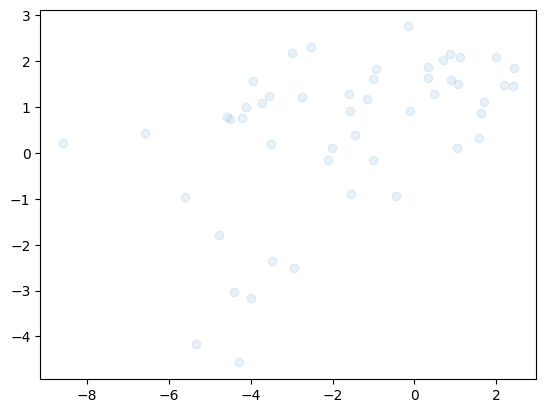

In [29]:
plt.scatter(guide.median()["mean"].cpu().log(), guide.median()["dispersion"].cpu().log(), alpha=0.1)

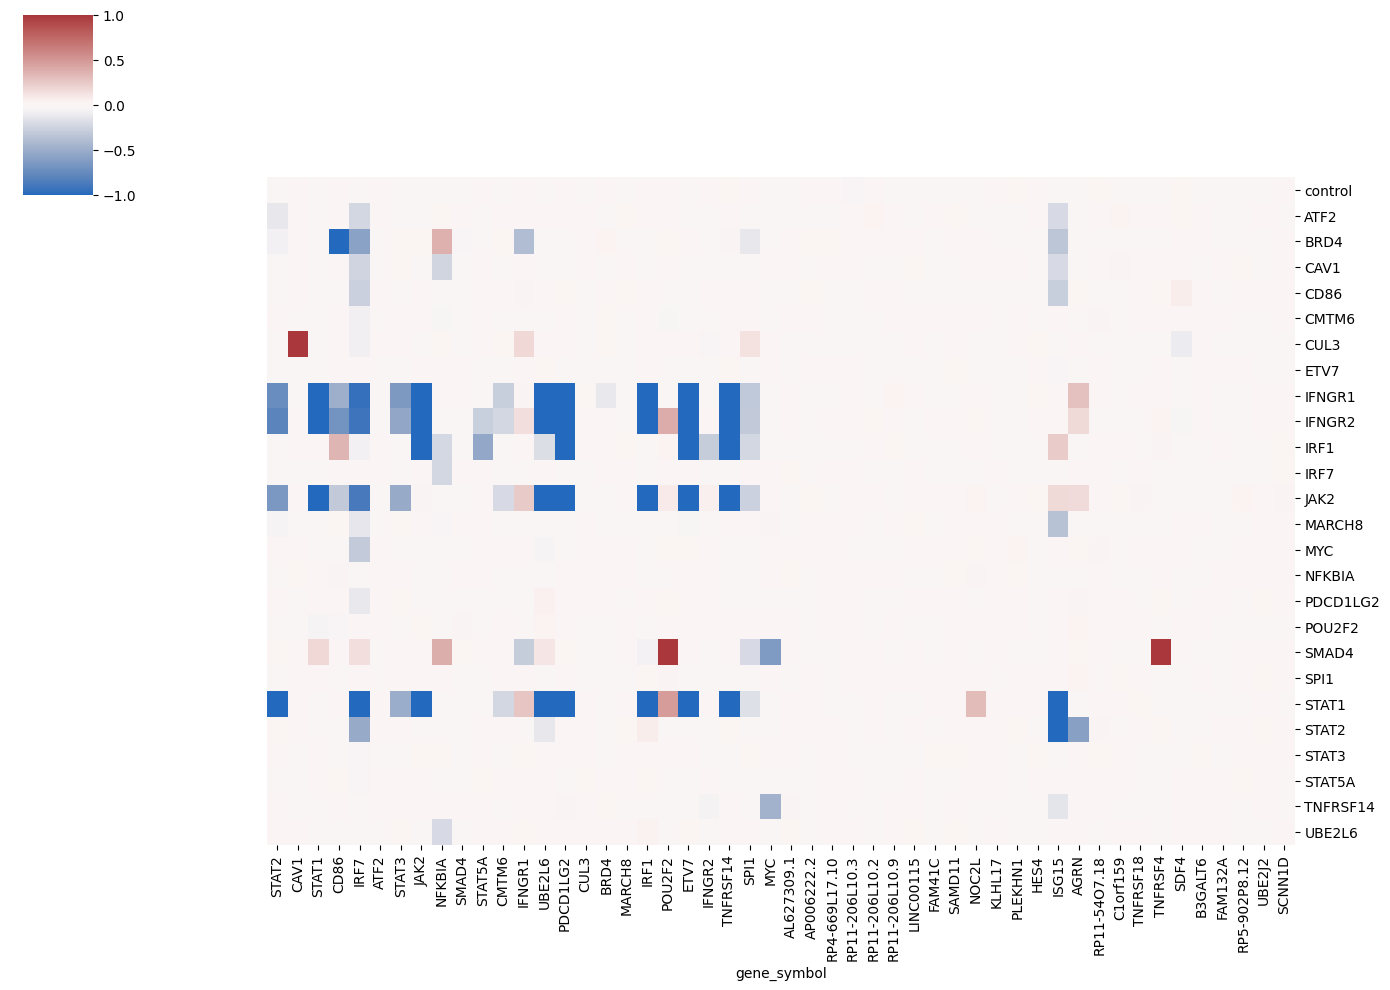

In [30]:
sns.clustermap(
    effects_df,
    vmax=1,
    vmin=-1,
    cmap="vlag",
    metric="cosine",
    figsize=(14, 10),
    col_cluster=False,
    row_cluster=False
)

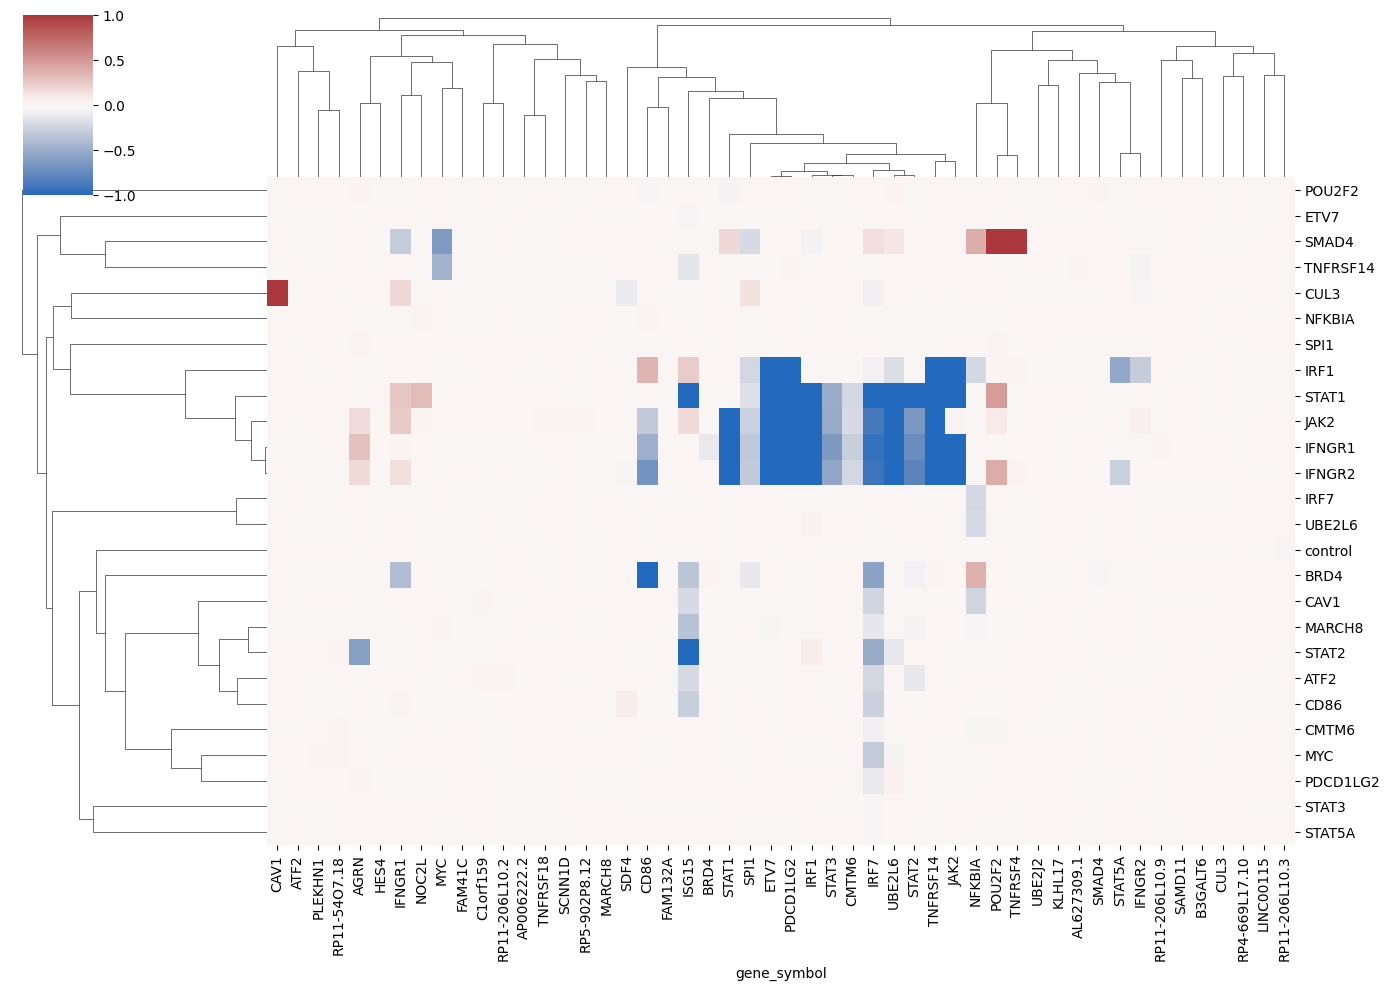

In [31]:
sns.clustermap(
    effects_df[hvgs], vmax=1, vmin=-1, cmap="vlag", metric="cosine", figsize=(14, 10)
)

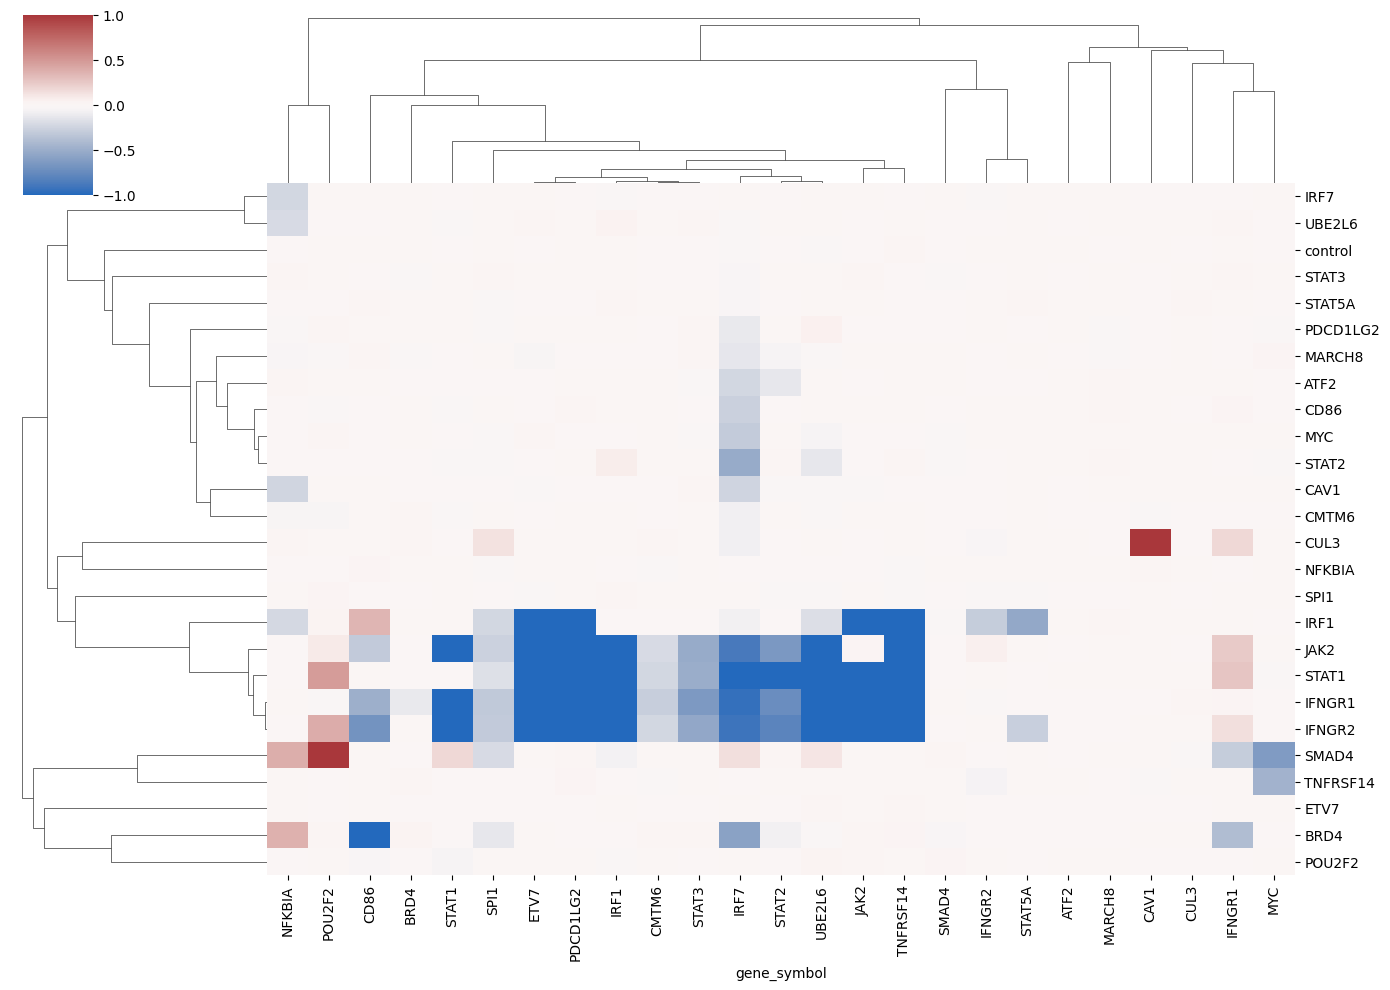

In [32]:
sns.clustermap(
    effects_df[[g for g in plot_genes if g in effects_df.columns]], vmax=1, vmin=-1, cmap="vlag", metric="cosine", figsize=(14, 10)
)

In [33]:
if not smoke_test:
    pyro.get_param_store().save("params.save")

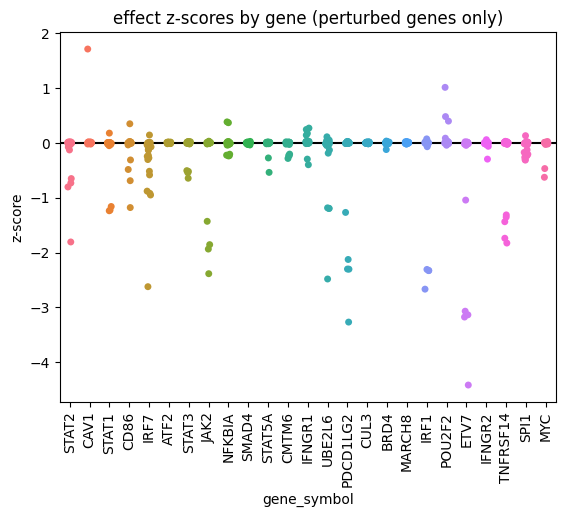

In [34]:
n_plot_genes = 25
sns.stripplot(effects_df.iloc[:, :n_plot_genes])
# sns.stripplot(effects_df[[g for g in plot_genes if g in effects_df.columns]])
#
plt.axhline(0, color="black")
plt.xticks(rotation=90)
plt.ylabel("z-score")
plt.title("effect z-scores by gene (perturbed genes only)")
plt.show()

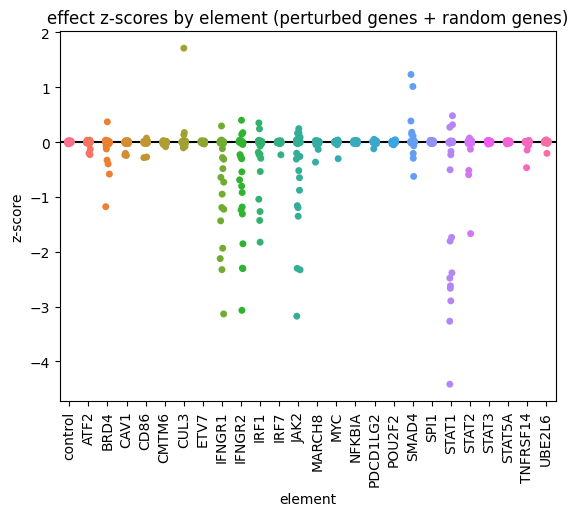

In [35]:
sns.stripplot(effects_df.T, alpha=1)
plt.xticks(rotation=90)
plt.axhline(0, color="black")
plt.ylabel("z-score")
plt.xlabel("element")
plt.title("effect z-scores by element (perturbed genes + random genes)")
plt.show()

In [36]:
effects_df.T["CMTM6"].sort_values()

gene_symbol
IRF7            -0.083934
POU2F2          -0.042539
NFKBIA          -0.039720
STAT1           -0.028756
C1orf159        -0.022457
CAV1            -0.020053
UBE2L6          -0.016875
RP4-669L17.10   -0.013473
UBE2J2          -0.011994
KLHL17          -0.010767
CMTM6           -0.010742
MYC             -0.010208
RP5-902P8.12    -0.009652
HES4            -0.008478
AGRN            -0.008427
CUL3            -0.007704
IFNGR2          -0.005482
IFNGR1          -0.004214
MARCH8          -0.004108
RP11-206L10.3   -0.003120
ETV7            -0.001759
SMAD4           -0.001625
ATF2            -0.000250
RP11-206L10.2   -0.000249
STAT5A           0.000291
CD86             0.000415
IRF1             0.000458
SPI1             0.001939
TNFRSF18         0.003157
B3GALT6          0.003813
TNFRSF14         0.004704
PDCD1LG2         0.005341
STAT3            0.005583
AL627309.1       0.005630
SDF4             0.006341
JAK2             0.006396
LINC00115        0.006723
ISG15            0.007801


In [37]:
# alpha = 0.001
# level = alpha / (n_genes * n_elements)
# low, high = guide.quantiles([level, 1 - level])["trans_effect"]
# (low < 0) & (high > 0)

In [38]:
# guide.median()

In [39]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

Currently broken: discrete MAP inference

In [ ]:
# if "subsample_size" in kwargs:
#     kwargs.pop("subsample_size")
guide_trace = poutine.trace(guide).get_trace(*args, **kwargs)  # record the globals
trained_model = poutine.replay(model, trace=guide_trace)  # replay the globals

args_sim = (None, *args[1:])
counts_simulated = trained_model(*args_sim, **kwargs)


# def classifier(args, temperature=0):
#     inferred_model = infer_discrete(
#         trained_model, temperature=temperature, first_available_dim=-3
#     )  # avoid conflict with data plate
#     trace = poutine.trace(inferred_model).get_trace(*args, **kwargs)
#     return trace.nodes["has_guide"]["value"]

adata_subset.obs["perturbation"]
# print(classifier(args))

In [ ]:
# import seaborn as sns

# # sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# gene_idx = 0
# counts_simulated_col = counts_simulated[:, gene_idx]
# counts_real_col = adata_subset[:, gene_idx].X.todense().A1
# max_count = int(max(counts_simulated_col.max(), counts_real_col.max()))
# # counts_simulated_col.shape
# # perts.shape
# plot_guides = ["control"] + [f"STAT1g{i}" for i in range(1, 5)]
# for guide_id in plot_guides:
#     perts = adata_subset.obs["perturbation"].str.contains(guide_id).values
#     # sns.scatterplot(x=counts_real_col[perts], y=counts_simulated_col[perts], label=guide_id, alpha=0.1)
#     # sns.violinplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     # sns.histplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     plt.title(guide_id)
#     sns.histplot(x=counts_real_col[perts], bins=range(max_count + 1), label="real")
#     sns.histplot(x=counts_simulated_col[perts], bins=range(max_count + 1), label="simulated")
#     plt.legend()
#     plt.semilogy()
#     plt.show()

In [ ]:
# import seaborn as sns

# # sns.violinplot(x=adata[:,"STAT1"].X.todense().squeeze(), y=adata.obs["guide_id"].str.contains("STAT1").values.squeeze())
# counts_simulated_col = counts_simulated[:, 0]
# counts_simulated_col.shape
# perts.shape
# plot_guides = [f"STAT1g{i}" for i in range(1, 5)] + ["control"]
# for guide_id in plot_guides:
#     perts = adata_subset.obs["perturbation"].str.contains(guide_id).values
#     # sns.violinplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     # sns.histplot(x=counts_simulated_col[perts], label=guide_id, binwidth=1, stat="density")
#     sns.kdeplot(x=counts_simulated_col[perts], label=guide_id)
#     # plt.show()
# plt.legend()

In [ ]:
print(kwargs)

In [ ]:
for k, v in guide.median().items():
    print(k, v.shape, v.dtype)

In [ ]:
for a in args:
    print(a.shape, a.dtype)
for k, v in kwargs.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape, v.dtype)
    else:
        print(k, v)

In [ ]:
guide_trace = poutine.trace(guide).get_trace(*args, **kwargs)  # record the globals
trained_model = poutine.replay(
    poutine.block(model, hide=["is_target"]), trace=guide_trace
)  # replay the globals


def classifier(args, kwargs, temperature=0):
    inferred_model = infer_discrete(
        trained_model, temperature=temperature, first_available_dim=-5
    )
    trace = poutine.trace(inferred_model).get_trace(*args, **kwargs)
    return trace.nodes["affected"]["value"]


map_labels = classifier(args, kwargs, temperature=0)
map_labels
# adata_subset.obs[["perturbation"]].assign(affected=map_labels).value_counts(["perturbation", "affected"])
# x.value_counts()
# torch.mean(classifier((None, perturbations), kwargs))

In [ ]:
plt.hist(
    guide.median()["perturbation_score"].ravel().detach().cpu()
    * map_labels.ravel().detach().cpu(),
    bins=100,
)

In [ ]:
n_posterior_samples = 100
posterior_samples = (
    sum(classifier(args, kwargs, temperature=1) for _ in range(n_posterior_samples))
    / n_posterior_samples
)
posterior_samples.mean()
plt.hist(posterior_samples.squeeze().detach().cpu())
# plt.semilogy()

In [ ]:
sns.kdeplot(
    x=posterior_samples.squeeze().detach().cpu(),
    hue=adata_subset.obs["element"].values.squeeze(),
    common_norm=False,
    # hue_order=["IFNGR1", "IFNGR2","STAT1", "STAT2", "control"],
)

In [ ]:
tolerance = 0.01
posterior_samples[
    (posterior_samples < (1 - tolerance)) & (posterior_samples > tolerance)
]